## Test 1 APCEMM PCE Creation

In [1]:
# APCEMM Application of PCE
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from numpy.linalg import eig
from scipy.interpolate import CubicSpline
import totalOrderMultiIndexSet
from sklearn.neighbors import KernelDensity
from numpy.polynomial.hermite_e import HermiteE
from matplotlib.lines import Line2D

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cdsapi

plt.rcParams["figure.figsize"] = (10, 6)
import tqdm
import time

In [2]:
### FUNCTION LIBRARY ###

def PCE():
    
    print("Started!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    c, alpha_set = compute_c()
    multiindices = alpha_set.shape[0]
    
    print("Got c and alpha!")

    He_array = np.zeros((multiindices, mc_runs))
    u_evals = np.ones(timesteps)
    
    print("Started MC runs!")

    comparison_samples_matrix = get_samples_matrix_online(mc_runs)

    for i in tqdm.tqdm(range(mc_runs)): # for each MC run
        u_evals = np.vstack((u_evals, solve_u(comparison_samples_matrix)))
        
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = comparison_samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Get rid of first row of ones
    true_output = u_evals[1:,:]

    # Solve for the Least Squares solution
    predicted_output = c.T @ He_array
    
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    return predicted_output.T, true_output, c, alpha_set

def compute_c():
    
    c_samples_matrix = get_samples_matrix_offline(training_runs)
    
    alpha_set = get_alpha_set()
    print("alpha set shape: ", alpha_set.shape)

    c_multiindices = alpha_set.shape[0]

    V = np.zeros((training_runs, c_multiindices)) # Vandermonde Matrix: Timesteps x Degree of Polynomial

    for i in tqdm.tqdm(range(training_runs)):
        for j in range(c_multiindices):
            current_alpha = alpha_set[j, :]
            c_samples_matrix_He = c_samples_matrix[i, :]
            V[i, j] = compute_He(c_samples_matrix_He, current_alpha) / np.sqrt(np.product(sc.special.factorial(current_alpha)))
    
    f = solve_u(c_samples_matrix) # f should be same dimension as V (Training_runs x Degree of Polynomial)
    
    c = np.linalg.solve(V.T @ V, V.T @ f)
    
    return c, alpha_set

def func_eval_offline(timesteps, samples_matrix):
    training_samples_matrix_offline_OUTPUTS = training_samples_matrix_offline[:,:,1]
    return training_samples_matrix_offline_OUTPUTS

def dummy_func_eval_online(timesteps, samples_array):

    true_output = np.zeros_like(samples_array)
    for t in range(0, timesteps):
        true_output[:,t] = samples_array[:,t] + (np.sin(2*np.pi*(t+1)/timesteps))
    
    return true_output

def get_samples_matrix_offline(training_runs):
    training_samples_matrix_offline_INPUTS = training_samples_matrix_offline[:,:,0]
    return training_samples_matrix_offline_INPUTS
    

def get_samples_matrix_online(runs):
    return np.random.normal(mean_Y, sigma_Y, size = (runs, timesteps)) # was 0,1

def get_alpha_set():
    return totalOrderMultiIndexSet.totalOrderMultiIndices(poly_dim, max_deg)

def compute_He(Z, alpha):
    res = 1
    for alpha_i, z_i in zip(alpha, Z):
        res = res * HermiteE.basis(deg = alpha_i)(z_i)
    return res

def solve_u(samples_matrix):
    
    u_sol = func_eval_offline(timesteps, samples_matrix) #NOT SURE
    return u_sol

#-----------------------------------------------------------------------------------

def validate_PCE(samples_matrix, c, alpha_set):
    multiindices = alpha_set.shape[0]
    He_array = np.zeros((multiindices, validation_runs))
    u_evals = np.ones(timesteps)

    for i in tqdm.tqdm(range(validation_runs)): # for each MC run
        u_evals = np.vstack((u_evals, solve_u(samples_matrix)))
        
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Get rid of first row of ones
    true_output = u_evals[1:,:]

    # Solve for the Least Squares solution
    predicted_output = (c.T @ He_array).T

    return predicted_output, true_output

In [3]:
# Define constants
training_runs = 10 # Number of APCEMM runs for training
timesteps = 73 # Number of samples per APCEMM run (this is the number of timesteps per run) # 20 hours
max_deg = 1 # Maximum value of sum of degrees across the number of uncertain variables (AKA sum of each row of alpha_set must be less than or equal to the max_deg)
poly_dim = 1 # Number of random variables
mc_runs = 1 # Number of PCE runs
training_samples_matrix_offline = np.load('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/test_1/training_sample_matrix.npy') # Import APCEMM training data

#FOR TESTING
mean_Y = 0
sigma_Y = 0.5 #squared value?

In [4]:
start_time = time.time()

# Call PCE function
predicted_output, training_output, c, alpha = PCE()

Started!
--- 0.0 minutes elapsed ---
alpha set shape:  (2, 1)


100%|██████████| 10/10 [00:00<00:00, 3156.70it/s]


Got c and alpha!
Started MC runs!


100%|██████████| 1/1 [00:00<00:00, 2082.57it/s]

--- 0.0 minutes elapsed ---


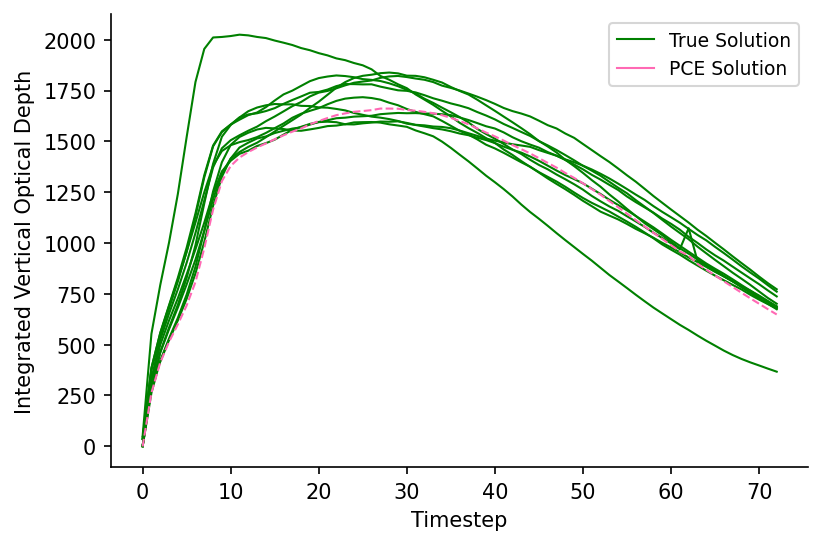

In [5]:
lw = 1
fig, ax = plt.subplots(dpi = 150)
for idx in range(training_runs):
    ax.plot(list(range(0,timesteps)), training_output[idx, :], label = "True", color = "green", lw = lw)
for idx in range(mc_runs):    
    ax.plot(list(range(0,timesteps)), predicted_output[idx, :], label = "PCE", color = "hotpink", ls = "dashed", lw = lw)
    
ax.set_xlabel(xlabel = r"Timestep")
ax.set_ylabel(ylabel = r"Integrated Vertical Optical Depth")

custom_lines = [Line2D([0], [0], color="green", lw=1), Line2D([0], [0], color="hotpink", lw=1)] # 

ax.legend(custom_lines, ['True Solution', 'PCE Solution'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

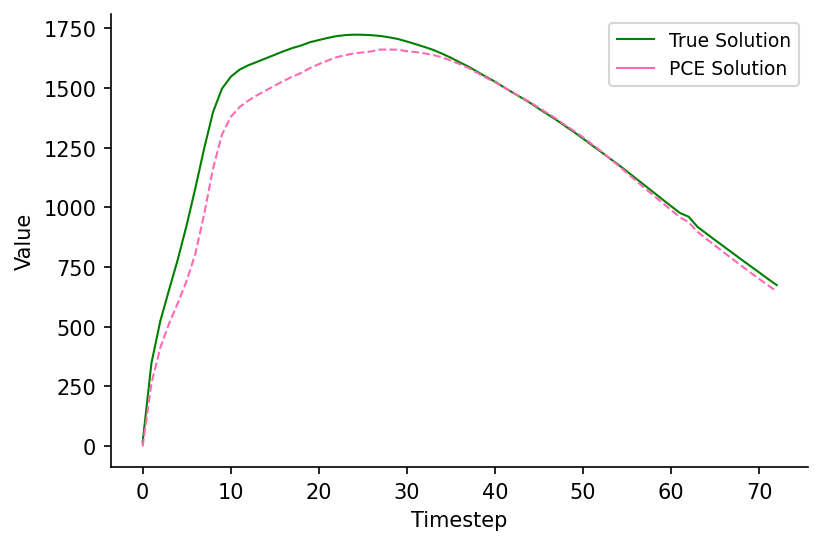

In [6]:
lw = 1
fig, ax = plt.subplots(dpi = 150)

ax.plot(list(range(0,timesteps)), training_output.mean(axis=0), label = "True", color = "green", lw = lw)
ax.plot(list(range(0,timesteps)), predicted_output.mean(axis=0), label = "PCE", color = "hotpink", ls = "dashed", lw = lw)

# ax.set_xlim(0,1)
ax.set_xlabel(xlabel = r"Timestep")
ax.set_ylabel(ylabel = r"Value")

custom_lines = [Line2D([0], [0], color="green", lw=1), Line2D([0], [0], color="hotpink", lw=1)] # 

ax.legend(custom_lines, ['True Solution', 'PCE Solution'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

In [7]:
# Use surrogates to compute Sobol analysis